# Spatial plots — derived_usgs datasets (Ogallala Aquifer)

Maps every gridded + point dataset under `derived_usgs/` that feeds the
Temporal Buffering Index analysis (see `TBI_DOCUMENTATION.md` §11):

| file | variable(s) plotted |
|---|---|
| `aquifer_mask_4km.nc` | `aquifer_mask` (0 outside / 1 inside) |
| `dWL_predev_to_2019_ft_4km.nc` | `dWL_predev_to_2019` [ft, negative = decline] |
| `dWL_2017_to_2019_ft_4km.nc` | `dWL_2017_to_2019` [ft] |
| `GDE_30arcsec_Ogallala_CF.nc` | all 5 GDE layers (Rohde et al. 2024) |
| `GW_wells_HPA_CF.nc` | well locations + per-well water-level changes (CF point data) |

Conventions used in every map: `hp_bound2010.shp` outline drawn in black,
faint dotted lon/lat grid. Files are opened **read-only**; figures go to
`derived_usgs_plots/`. Requirements: `xarray`, `numpy`, `matplotlib`,
`geopandas`.

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, ListedColormap
from pathlib import Path
import geopandas as gpd

In [2]:
# ---- config ----
BASE = Path(r"G:/MSU_GWB/datasets")
DERIVED = BASE / "derived_usgs"
SHP_PATH = BASE / "high_plains_quifer" / "hp_bound2010.shp"
OUT_DIR = BASE / "derived_usgs_plots"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FILES = {
    "mask": DERIVED / "aquifer_mask_4km.nc",
    "dwl_long": DERIVED / "dWL_predev_to_2019_ft_4km.nc",
    "dwl_recent": DERIVED / "dWL_2017_to_2019_ft_4km.nc",
    "gde": DERIVED / "GDE_30arcsec_Ogallala_CF.nc",
    "wells": DERIVED / "GW_wells_HPA_CF.nc",
}
for k, p in FILES.items():
    print(f"{k:<10} exists={p.exists()}  {p.name}")
print("output:", OUT_DIR)

mask       exists=True  aquifer_mask_4km.nc
dwl_long   exists=True  dWL_predev_to_2019_ft_4km.nc
dwl_recent exists=True  dWL_2017_to_2019_ft_4km.nc
gde        exists=True  GDE_30arcsec_Ogallala_CF.nc
wells      exists=True  GW_wells_HPA_CF.nc
output: G:\MSU_GWB\datasets\derived_usgs_plots


In [3]:
# ---- ROI boundary for map overlays ----
bnd = gpd.read_file(SHP_PATH).to_crs("EPSG:4326")
print(f"boundary: {len(bnd)} polygon features")

boundary: 199 polygon features


In [4]:
# ---- shared helpers ----
def grid_extent(da):
    """(extent, origin) for imshow from 1-D x/y coords, either y order."""
    x = da["x"].values
    y = da["y"].values
    dx = float(x[1] - x[0])
    dy = float(y[1] - y[0])
    if dy < 0:  # rows run north -> south
        return ([x[0] - dx / 2, x[-1] + dx / 2,
                 y[-1] + dy / 2, y[0] - dy / 2], "upper")
    return ([x[0] - dx / 2, x[-1] + dx / 2,
             y[0] - dy / 2, y[-1] + dy / 2], "lower")


def decorate(ax, title, xlabel="Longitude (°E)", ylabel="Latitude (°N)"):
    ax.set_title(title, fontsize=10)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    bnd.boundary.plot(ax=ax, edgecolor="black", linewidth=0.9)
    ax.grid(True, which="major", color="gray", alpha=0.35,
            linewidth=0.5, linestyle=":")
    ax.set_axisbelow(True)


def plot_grid(da, title, cmap="viridis", vmin=None, vmax=None, norm=None,
              cbar_label="", figsize=(7.5, 7.0)):
    extent, origin = grid_extent(da)
    fig, ax = plt.subplots(figsize=figsize)
    img = np.ma.masked_invalid(np.asarray(da.values, dtype="float64"))
    im = ax.imshow(img, extent=extent, origin=origin, cmap=cmap,
                   vmin=vmin, vmax=vmax, norm=norm, interpolation="nearest")
    decorate(ax, title)
    cb = fig.colorbar(im, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label(cbar_label)
    fig.tight_layout()
    return fig, ax

<xarray.Dataset> Size: 56kB
Dimensions:       (y: 287, x: 181)
Coordinates:
  * y             (y) float64 2kB 43.64 43.6 43.56 43.52 ... 31.81 31.77 31.73
  * x             (x) float64 1kB -105.9 -105.8 -105.8 ... -96.36 -96.3 -96.25
Data variables:
    aquifer_mask  (y, x) uint8 52kB ...
Attributes:
    long_name:    High Plains aquifer boundary (hp_bound2010)
    flag_values:  0 outside, 1 inside
    units:        1
inside px: 21,259 / 51,947 (40.9%)


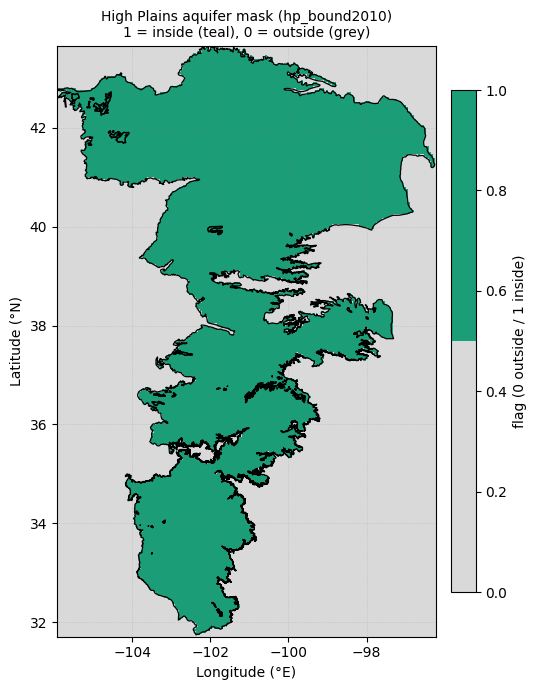

In [5]:
# ---- 1. aquifer mask ----
ds = xr.open_dataset(FILES["mask"], decode_cf=True)
print(ds)
m = ds["aquifer_mask"].values
n_in = int((m == 1).sum())
print(f"inside px: {n_in:,} / {m.size:,} ({100 * n_in / m.size:.1f}%)")
fig, ax = plot_grid(
    ds["aquifer_mask"], "High Plains aquifer mask (hp_bound2010)\n"
    "1 = inside (teal), 0 = outside (grey)",
    cmap=ListedColormap(["#d9d9d9", "#1b9e77"]), vmin=0, vmax=1,
    cbar_label="flag (0 outside / 1 inside)")
fig.savefig(OUT_DIR / "aquifer_mask_map.png", dpi=150)
plt.show()
ds.close()

valid px: 21,250 | p1=-200.0 med=0.0 p99=15.4 ft  (negative = decline)


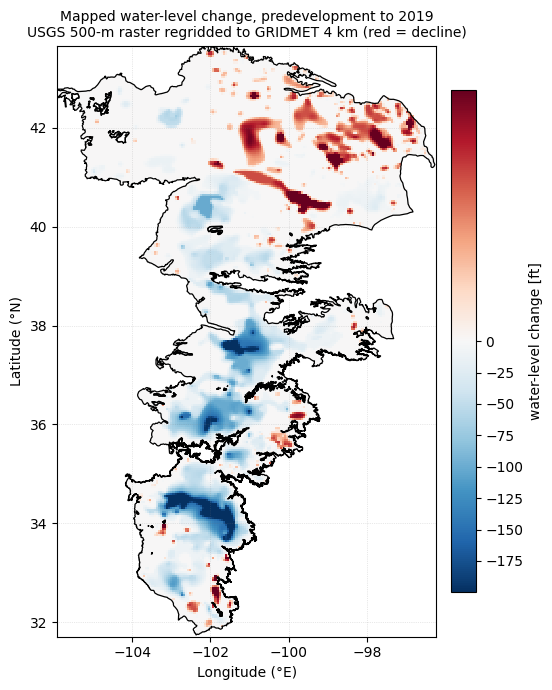

In [6]:
# ---- 2. water-level change: predevelopment (~1950) -> 2019 ----
ds = xr.open_dataset(FILES["dwl_long"], decode_cf=True)
da = ds["dWL_predev_to_2019"]
v = da.values[np.isfinite(da.values)]
lo, hi = float(np.percentile(v, 1)), float(np.percentile(v, 99))
print(f"valid px: {v.size:,} | p1={lo:.1f} med={np.median(v):.1f} "
      f"p99={hi:.1f} ft  (negative = decline)")
fig, ax = plot_grid(
    da, "Mapped water-level change, predevelopment to 2019\n"
    "USGS 500-m raster regridded to GRIDMET 4 km (red = decline)",
    cmap="RdBu_r", norm=TwoSlopeNorm(vmin=lo, vcenter=0, vmax=hi),
    cbar_label="water-level change [ft]")
fig.savefig(OUT_DIR / "dwl_predev_to_2019_map.png", dpi=150)
plt.show()
ds.close()

valid px: 21,250 | p1=-3.85 med=0.00 p99=4.57 ft  (negative = decline)


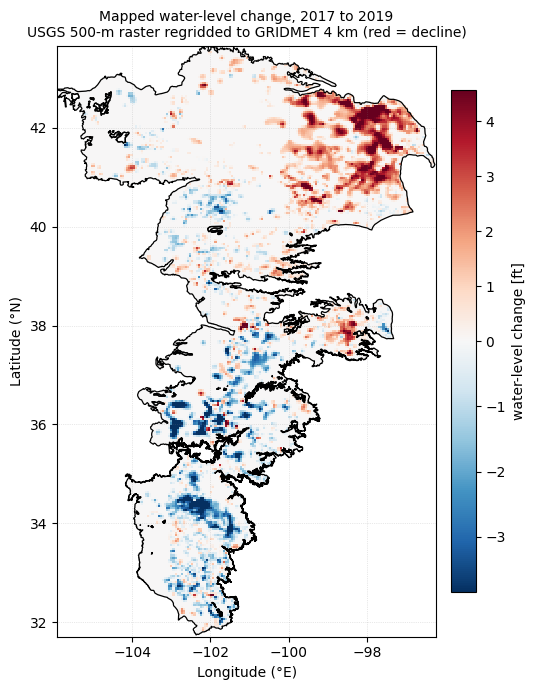

In [7]:
# ---- 3. water-level change: 2017 -> 2019 ----
ds = xr.open_dataset(FILES["dwl_recent"], decode_cf=True)
da = ds["dWL_2017_to_2019"]
v = da.values[np.isfinite(da.values)]
lo, hi = float(np.percentile(v, 1)), float(np.percentile(v, 99))
print(f"valid px: {v.size:,} | p1={lo:.2f} med={np.median(v):.2f} "
      f"p99={hi:.2f} ft  (negative = decline)")
fig, ax = plot_grid(
    da, "Mapped water-level change, 2017 to 2019\n"
    "USGS 500-m raster regridded to GRIDMET 4 km (red = decline)",
    cmap="RdBu_r", norm=TwoSlopeNorm(vmin=lo, vcenter=0, vmax=hi),
    cbar_label="water-level change [ft]")
fig.savefig(OUT_DIR / "dwl_2017_to_2019_map.png", dpi=150)
plt.show()
ds.close()

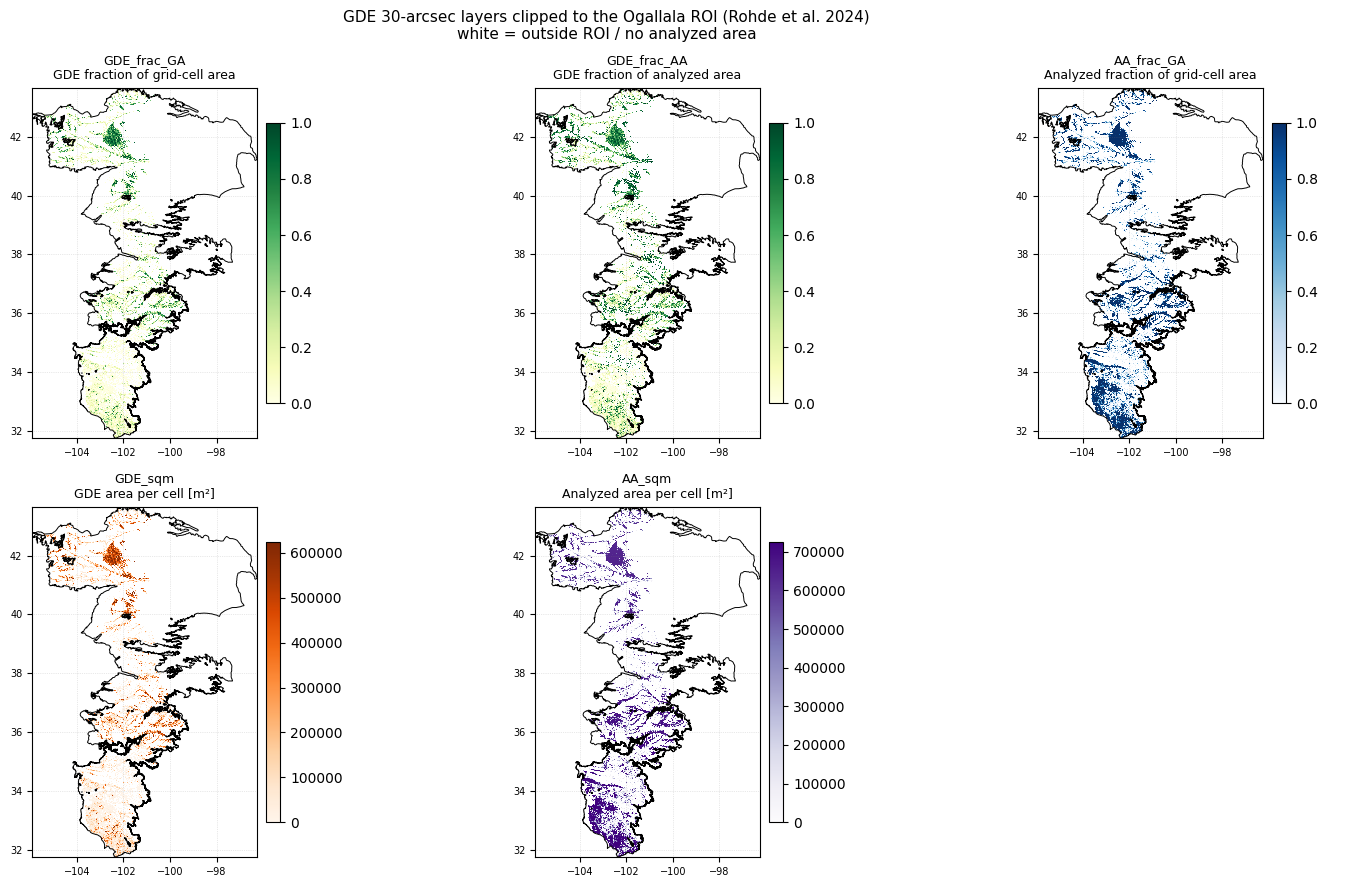

In [8]:
# ---- 4. GDE layers: overview panel (all 5 bands) ----
ds = xr.open_dataset(FILES["gde"], decode_cf=True)
specs = [
    ("GDE_frac_GA", "GDE fraction of grid-cell area", "YlGn", 0, 1),
    ("GDE_frac_AA", "GDE fraction of analyzed area", "YlGn", 0, 1),
    ("AA_frac_GA", "Analyzed fraction of grid-cell area", "Blues", 0, 1),
    ("GDE_sqm", "GDE area per cell [m²]", "Oranges", 0,
     float(np.nanpercentile(ds["GDE_sqm"].values, 99))),
    ("AA_sqm", "Analyzed area per cell [m²]", "Purples", 0,
     float(np.nanpercentile(ds["AA_sqm"].values, 99))),
]
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for ax, (name, title, cmap, vmin, vmax) in zip(axes.flat, specs):
    da = ds[name]
    extent, origin = grid_extent(da)
    img = np.ma.masked_invalid(np.asarray(da.values, dtype="float64"))
    im = ax.imshow(img, extent=extent, origin=origin, cmap=cmap,
                   vmin=vmin, vmax=vmax, interpolation="nearest")
    ax.set_title(f"{name}\n{title}", fontsize=9)
    bnd.boundary.plot(ax=ax, edgecolor="black", linewidth=0.7)
    ax.grid(True, which="major", color="gray", alpha=0.35,
            linewidth=0.5, linestyle=":")
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=7)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
axes.flat[-1].axis("off")
fig.suptitle("GDE 30-arcsec layers clipped to the Ogallala ROI "
             "(Rohde et al. 2024)\nwhite = outside ROI / no analyzed area",
             fontsize=11)
fig.tight_layout()
fig.savefig(OUT_DIR / "gde_overview_panel.png", dpi=150)
plt.show()
ds.close()

<xarray.Dataset> Size: 2MB
Dimensions:                   (station: 8222, obs: 20580)
Coordinates:
  * station                   (station) int32 33kB 0 1 2 3 ... 8219 8220 8221
    lat                       (station) float64 66kB ...
    lon                       (station) float64 66kB ...
  * obs                       (obs) int32 82kB 0 1 2 3 ... 20577 20578 20579
    time                      (obs) datetime64[ns] 165kB ...
Data variables: (12/14)
    site_badge                (station) |S24 197kB ...
    usgs_id                   (station) |S32 263kB ...
    station_name              (station) |S32 263kB ...
    state                     (station) |S4 33kB ...
    county                    (station) |S6 49kB ...
    source_dataset            (station) |S8 66kB ...
    ...                        ...
    dWL_pd19_supplemental_ft  (station) float32 33kB ...
    dWL_1980_2019_ft          (station) float32 33kB ...
    dWL_2017_2019_ft          (station) float32 33kB ...
    station_index 

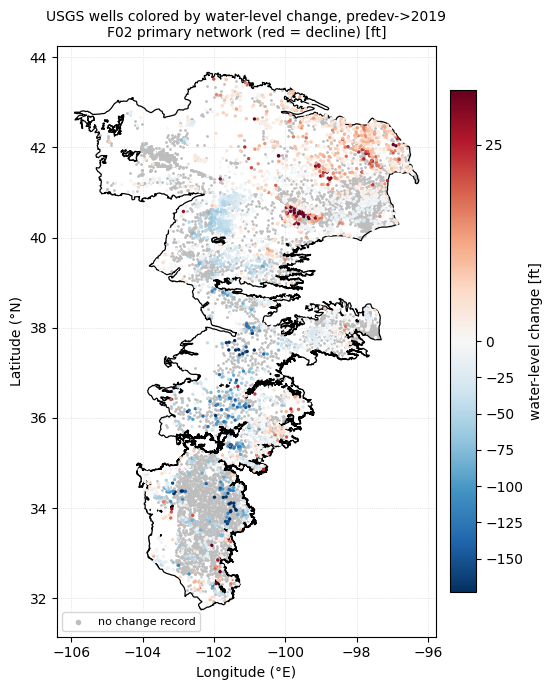

In [9]:
# ---- 5. wells: locations colored by predev->2019 change ----
ds = xr.open_dataset(FILES["wells"], decode_cf=True)
print(ds)
lon = ds["lon"].values
lat = ds["lat"].values
chg = ds["dWL_pd19_primary_ft"].values.astype("float64")
ok = np.isfinite(chg)
print(f"stations: {ds.sizes['station']:,} | obs records: {ds.sizes['obs']:,} | "
      f"with predev->2019 change: {ok.sum():,}")
print("time coverage:",
      str(ds["time"].values.min())[:10], "->", str(ds["time"].values.max())[:10])
fig, ax = plt.subplots(figsize=(7.5, 7.0))
ax.scatter(lon[~ok], lat[~ok], s=4, c="#bdbdbd", label="no change record",
           linewidths=0, zorder=2)
sc = ax.scatter(lon[ok], lat[ok], s=6, c=chg[ok], cmap="RdBu_r",
                norm=TwoSlopeNorm(vmin=float(np.nanpercentile(chg[ok], 1)),
                                  vcenter=0,
                                  vmax=float(np.nanpercentile(chg[ok], 99))),
                linewidths=0, zorder=3)
decorate(ax, "USGS wells colored by water-level change, predev->2019\n"
         "F02 primary network (red = decline) [ft]")
cb = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("water-level change [ft]")
ax.legend(markerscale=2, fontsize=8, loc="lower left")
fig.tight_layout()
fig.savefig(OUT_DIR / "wells_dwl_predev_to_2019_map.png", dpi=150)
plt.show()

stations with 2017->2019 change: 7,195


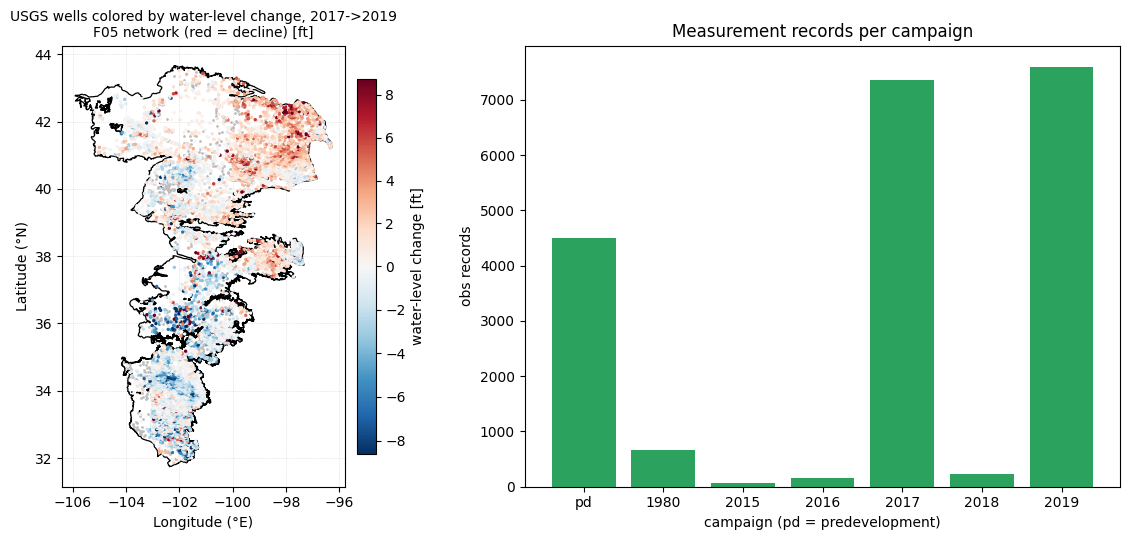

In [10]:
# ---- 6. wells: 2017->2019 change + campaign census ----
chg2 = ds["dWL_2017_2019_ft"].values.astype("float64")
ok2 = np.isfinite(chg2)
print(f"stations with 2017->2019 change: {ok2.sum():,}")
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
ax = axes[0]
ax.scatter(lon[~ok2], lat[~ok2], s=4, c="#bdbdbd", linewidths=0, zorder=2)
sc = ax.scatter(lon[ok2], lat[ok2], s=6, c=chg2[ok2], cmap="RdBu_r",
                norm=TwoSlopeNorm(vmin=float(np.nanpercentile(chg2[ok2], 1)),
                                  vcenter=0,
                                  vmax=float(np.nanpercentile(chg2[ok2], 99))),
                linewidths=0, zorder=3)
decorate(ax, "USGS wells colored by water-level change, 2017->2019\n"
         "F05 network (red = decline) [ft]")
cb = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("water-level change [ft]")
ax = axes[1]
camps, counts = np.unique(ds["campaign"].values, return_counts=True)
order = ["pd", "1980", "2015", "2016", "2017", "2018", "2019"]
labels = [c.decode() for c in camps]
mp = dict(zip(labels, counts))
ax.bar([c for c in order if c in mp], [mp[c] for c in order if c in mp],
       color="#2ca25f")
ax.set_title("Measurement records per campaign")
ax.set_xlabel("campaign (pd = predevelopment)")
ax.set_ylabel("obs records")
fig.tight_layout()
fig.savefig(OUT_DIR / "wells_dwl_2017_to_2019_and_campaigns.png", dpi=150)
plt.show()
ds.close()

**Notes for interpretation**

- Red = water-level **decline** (negative change); blue = rise. The long-term
  map (predev→2019) is dominated by declines in the central/southern aquifer,
  while 2017→2019 changes are an order of magnitude smaller (±~4 ft typical).
- Well points (`GW_wells_HPA_CF.nc`, CF point data, 8,222 stations / 20,580 obs)
  corroborate the gridded dWL rasters; grey points lack that epoch's change
  record. Campaigns: `pd` = predevelopment; `1980` only in the F03 supplemental
  network.
- GDE white areas = outside ROI **or** no analyzed area in the source product.
  Full layer definitions: `TBI_DOCUMENTATION.md` §11.14.

In [11]:
# ---- wrap-up ----
print("saved figures:")
for p in sorted(OUT_DIR.glob("*.png")):
    print(f"  {p.name}  ({p.stat().st_size/1e3:.0f} KB)")

saved figures:
  aquifer_mask_map.png  (158 KB)
  dwl_2017_to_2019_map.png  (207 KB)
  dwl_predev_to_2019_map.png  (201 KB)
  gde_overview_panel.png  (639 KB)
  wells_dwl_2017_to_2019_and_campaigns.png  (302 KB)
  wells_dwl_predev_to_2019_map.png  (314 KB)
